# Spatial Wavelet Transform - Kronecker Matrix Transform 
February 19, 2024

Transform the per image matrix transforms to flattened matrices so we can operate against flattened images.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from cc_src.chromatin_model import ChromatinModel
from src.config import load_yl_replicate1_rg1_alpha_vst_config

gene_name = 'CLB2'
config1 = load_yl_replicate1_rg1_alpha_vst_config()
chromatin_model = ChromatinModel(config1)
chromatin_model.load_mnase_gene(gene_name, 1)

Loading MNase reads for CLB2...Done.


In [3]:
chromatin_model.create_deconvolution_bins(smoothing=False)

Unflattened the input data is of shape: (16, 16, 50)
The size of our input data, G is: (16, 800)


In [9]:
G = chromatin_model.G

In [10]:
image_shape = chromatin_model.deconv_hist_unflattened.shape[1:]
image_shape

(16, 50)

In [187]:
import pywt 
from src.wavelets_2d_linalg import create_kron_wavelet2d_convolution_matrices

wavelet = pywt.Wavelet('bior4.4')

G_shape = chromatin_model.G.shape

In [413]:
# Let's compare to the normal deconstruction and recomposition of a single iamge
decomp_mats, reconst_mats = create_wavelet2d_convolution_matrices(wavelet, image_shape)

(down_lo_horizontal_mat, down_lo_vertical_mat, 
 down_hi_horizontal_mat, down_hi_vertical_mat) = decomp_mats

(up_lo_horizontal_mat, up_lo_vertical_mat, 
 up_hi_horizontal_mat, up_hi_vertical_mat) = reconst_mats

G_0 = G_imgs[0]


n, m = image_shape
horizontal_tranpose_shape = n, m//2,
coeffs_transpose_shape = m//2, n
up_transpose_mat = create_flattened_transpose_permutation_matrix(coeffs_transpose_shape)
down_transpose_mat = create_flattened_transpose_permutation_matrix(horizontal_tranpose_shape)

# Rearrange all of the operations such that the left-most side
# is our input, so we can translate to operating on the stack of images
L = G_0@down_lo_horizontal_mat

L_T = (L.flatten() @ down_transpose_mat).reshape(L.T.shape)
LL = (L_T@down_lo_vertical_mat)

recVL = LL@up_lo_vertical_mat
reconstructed_vertL_T = (recVL.flatten() @ up_transpose_mat).reshape(recVL.T.shape)
reconstructed = reconstructed_vertL_T@up_lo_horizontal_mat

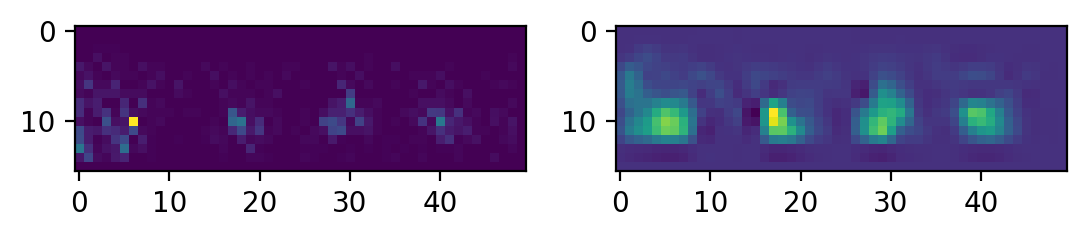

In [392]:
plt.subplot(1, 2, 1)
plt.imshow(G_0)
plt.subplot(1, 2, 2)
plt.imshow(reconstructed)

In [425]:

decomp_mats, reconst_mats = create_kron_wavelet2d_convolution_matrices(wavelet, image_shape)

(down_lo_horizontal_mat, down_lo_vertical_mat, 
 down_hi_horizontal_mat, down_hi_vertical_mat) = decomp_mats

(up_lo_horizontal_mat, up_lo_vertical_mat, 
 up_hi_horizontal_mat, up_hi_vertical_mat) = reconst_mats

up_transpose_mat = create_flattened_transpose_permutation_matrix(coeffs_transpose_shape)
down_transpose_mat = create_flattened_transpose_permutation_matrix(horizontal_tranpose_shape)
                                                                       

In [427]:
down_transpose_mat.shape, up_transpose_mat.shape

((400, 400), (400, 400))

In [440]:
G_0_flat = G_imgs[0].flatten()

L = (G_0_flat @ down_lo_horizontal_mat)
LL = L @ down_transpose_mat @ down_lo_vertical_mat.T


reVL = LL @ up_lo_vertical_mat.T
reconstructed = reVL @ up_transpose_mat @ up_lo_horizontal_mat


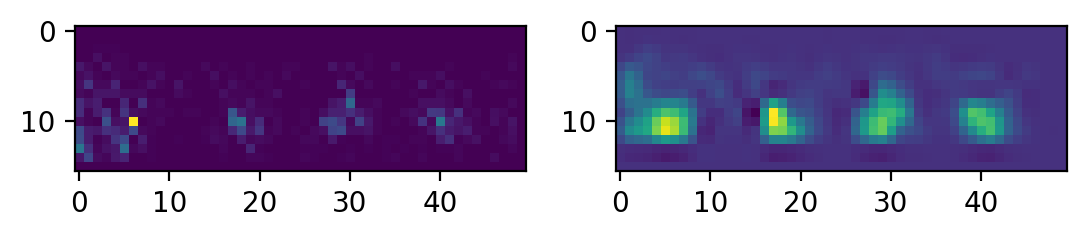

In [441]:
plt.subplot(1, 2, 1)
plt.imshow(G_0_flat.reshape(image_shape))
plt.subplot(1, 2, 2)
plt.imshow(reconstructed.reshape(image_shape))